Постановка задачи

Представьте, что вы агрегатор недвижимости. К вам поступает новая квартира, и нужно автоматически рекомендовать для неё справедливую цену аренды, основываясь на данных о **3 ближайших соседях** (k=3).

Признаки квартиры:

1. `Площадь` (в кв. метрах)
2. `Расстояние до метро` (в минутах пешком)

---

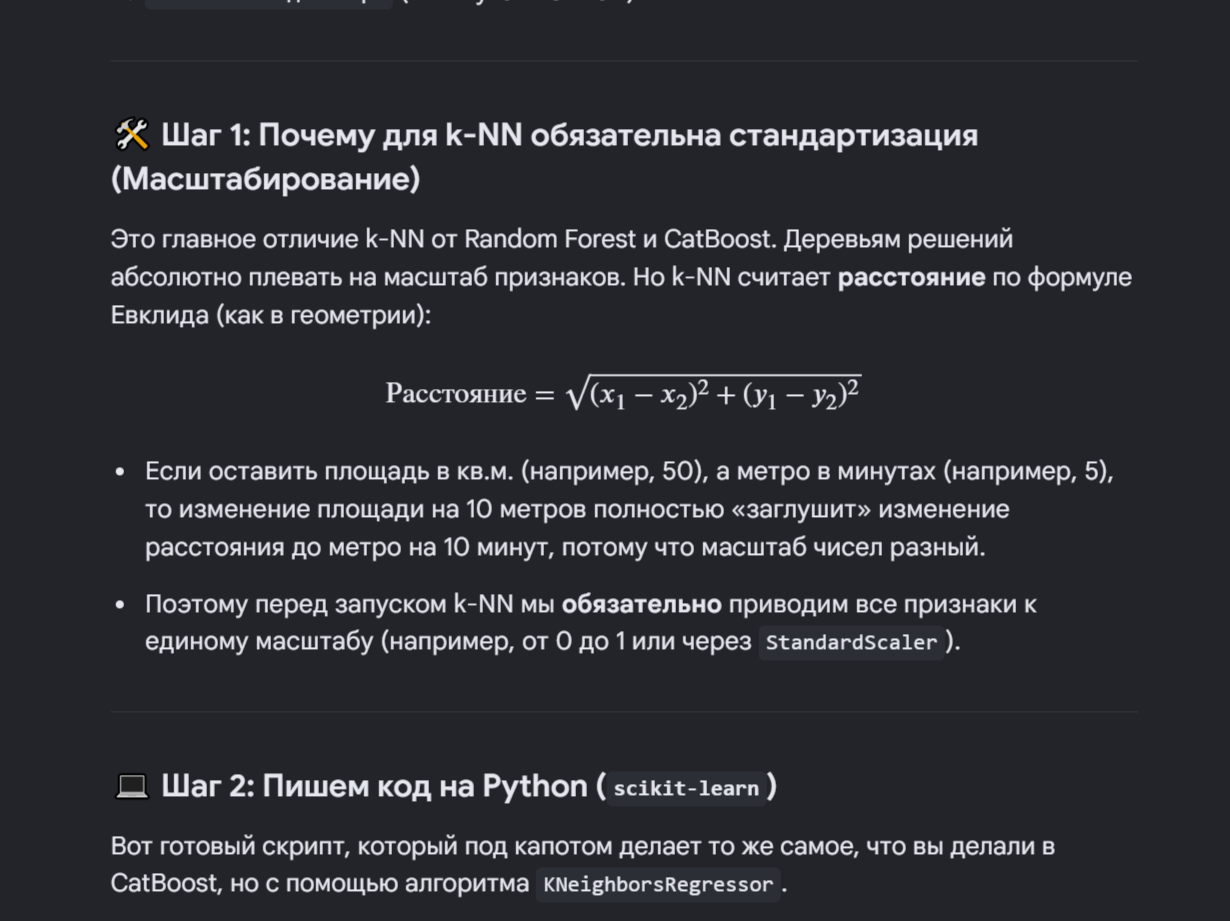

In [5]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train = np.array([
    [80, 3],
    [50, 2],
    [90, 15],
    [18, 1]
])

y_train = np.array([30, 32, 28, 15])

X_new = np.array([[50, 10]])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# Создаем и "обучаем" модель k-NN (берем 3-х ближайших соседей)
# weights='distance' - чтобы близкие соседи влияли на результат сильнее, чем дальние
# p = 1 | L = 1 - манхэттенское расстояние
# p = 2 | L = 2 - метрика Минковского
knn = KNeighborsRegressor(n_neighbors=3, weights='distance', p=2)
knn.fit(X_train_scaled, y_train) # Алгоритм просто запоминает точки

predicted_price = knn.predict(X_new_scaled)

print(f"Рекомендуемая цена аренды: {predicted_price[0]:.1f} тыс. руб.")

# Вычисляем разницы по координатам (дельта)
deltas = np.abs(X_train_scaled - X_new_scaled)

for i, d in enumerate(deltas):
    l1 = np.sum(d)
    l2 = np.sqrt(np.sum(d**2))
    print(f"Точка {i} (y={y_train[i]}): L1 = {l1:.3f} | L2 = {l2:.3f}")

Рекомендуемая цена аренды: 30.1 тыс. руб.
Точка 0 (y=30): L1 = 2.301 | L2 = 1.631
Точка 1 (y=32): L1 = 1.410 | L2 = 1.410
Точка 2 (y=28): L1 = 2.304 | L2 = 1.673
Точка 3 (y=15): L1 = 2.724 | L2 = 1.952


🔍 Как k-NN принял решение под капотом?

1. Он перевел параметры нашей новой квартиры `[50 метров, 10 минут]` в многомерную систему координат.
2. Посчитал геометрическое расстояние от этой точки до всех 5 квартир в базе данных.
3. Выбрал **3 самые близкие** по характеристикам квартиры (например, квартиру за 50к, за 75к и за 45к).
4. Взял их цены и посчитал среднее арифметическое: `(50 + 75 + 45) / 3 = 56.6`

⚖️ Сравнение: k-NN против CatBoost / Random Forest

|Критерий|k-NN|CatBoost / Random Forest|
|---|---|---|
|**Скорость обучения**|Мгновенно (просто сохраняет данные)|Медленно (строит сотни деревьев)|
|**Скорость предсказания**|**Медленно** (ищет соседей по всей базе)|Мгновенно (прогоняет через готовые формулы)|
|**Работа с текстом/категориями**|Плохо (сложно посчитать расстояние)|Идеально (CatBoost создан для этого)|
|**Размер модели на диске**|Весит столько же, сколько вся ваша БД|Весит мало (только структура деревьев)|

💡 В реальном продакшене k-NN редко используют как финальную модель для таблиц, так как CatBoost обычно точнее. Но k-NN незаменим, например, в **рекомендательных системах** (поиск 5 пользователей, похожих на вас, чтобы предложить им те же треки в Spotify).

---

#### Как автоматически подобрать идеальное количество соседей (k)?

Если взять k=1, модель будет слишком чувствительна к шуму (какой-нибудь сумасшедший выставил развалюху за 200к, и модель повторит эту ошибку). Это называется **переобучением** (Overfitting).  
Если взять k=100 на маленькой базе, модель просто вернет среднюю цену вообще всех квартир в городе. Это **недообучение** (Underfitting).

Чтобы найти золотую середину, используют метод **Кросс-валидации** (GridSearchCV). Мы заставим Python перебрать разные значения k (например, от 1 до 10), протестировать их на скрытых кусочках данных и выбрать то, где ошибка минимальна.

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

X_train = np.array([
    [80, 3],
    [50, 2],
    [90, 15],
    [18, 1]
])

y_train = np.array([30, 32, 28, 15])

X_new = np.array([[50, 10]])

# 3. Масштабирование признаков (Только для матрицы X!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_new_scaled = scaler.transform(X_new)

# 4. Настройка сетки параметров для k-NN
# Максимум 2 соседа, чтобы не ломать кросс-валидацию на 5 объектах
param_grid = {'n_neighbors': list(range(1, 2))}

# Создаем базовую модель со взвешиванием по расстоянию
knn_base = KNeighborsRegressor(weights='distance')

# 5. Автоматический подбор параметров с помощью кросс-валидации
# cv=2 означает, что данные поделятся на 2 части для проверки
grid_search = GridSearchCV(knn_base, param_grid, cv=2, scoring='neg_mean_absolute_error')
grid_search.fit(X_train_scaled, y_train)

# 6. Получение лучшей модели и финальный прогноз
best_knn = grid_search.best_estimator_
best_k = grid_search.best_params_['n_neighbors']
predicted_price = best_knn.predict(X_new_scaled)

print(f"📊 Лучшее число соседей (k): {best_k}")
print(f"💰 Рекомендуемая цена аренды: {predicted_price[0]:.1f} тыс. руб.")


📊 Лучшее число соседей (k): 1
💰 Рекомендуемая цена аренды: 32.0 тыс. руб.


Резюме: что выбрать?

- Используйте `p=2` (L2) по умолчанию. Она лучше работает в стандартных физических и геометрических задачах, так как учитывает корреляцию признаков «по прямой».
- Используйте `p=1` (L1), если в данных много **шума и аномалий (выбросов)**. L1 не возводит ошибки в квадрат, поэтому случайная точка-выброс не утянет предсказание модели далеко в сторону.

---